# BÀI TẬP: E-COMMERCE DATA (ONLINE RETAIL)
**Nguồn:** kaggle.com/datasets/carrie1/ecommerce-data (541,909 dòng)


## Setup

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv'

df = pd.read_csv(csv_path, encoding='ISO-8859-1', on_bad_lines='skip')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [6]:
# TODO
print('Số dòng dữ liệu: ', df.shape[0], '.Số cột dữ liệu: ' ,df.shape[1])
df.info()

Số dòng dữ liệu:  541909 .Số cột dữ liệu:  8
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 33.1 MB


## A.2. Missing values & Duplicate data

In [8]:
# TODO
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else 'Không có dữ liệu bị thiếu')
print()
print('Duplicate row (toàn bộ): ', df.duplicated().sum())


Description      1454
CustomerID     135080
dtype: int64

Duplicate row (toàn bộ):  5268


## A.3. Invalid values

In [23]:
# TODO
print('Số sản phẩm có số lượng <= 0: ', (df['Quantity'] <= 0).sum())
print('Số sản phẩm có giá <= 0:', (df['UnitPrice'] <= 0).sum())
print("Số lượng đơn hàng hoàn trả (Mã bắt đầu bằng 'C'):", df['InvoiceNo'].astype(str).str.startswith('C', na=False).sum())
print("Số dòng thiếu mã khách hàng (CustomerID là Null):", df['CustomerID'].isnull().sum())

Số sản phẩm có số lượng <= 0:  10624
Số sản phẩm có giá <= 0: 2517
Số lượng đơn hàng hoàn trả (Mã bắt đầu bằng 'C'): 9288
Số dòng thiếu mã khách hàng (CustomerID là Null): 135080


## A.4. Create a new column
Làm sạch dữ liệu (loại Quantity<=0, UnitPrice<=0), tạo cột `Sales` = Quantity * UnitPrice.

In [24]:
# TODO
df_clean = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()
df_clean['Sales'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [25]:
# TODO
for col in ['Quantity', 'UnitPrice', 'Sales']:
    mean_ = df_clean[col].mean()
    median_ = df_clean[col].median()
    mode_ = df_clean[col].mode()[0]
    
    print(f"--- {col.upper()} ---")
    print(f"Mean   = {mean_:.2f}")
    print(f"Median = {median_:.2f}")
    print(f"Mode   = {mode_:.2f}\n")

--- QUANTITY ---
Mean   = 10.54
Median = 3.00
Mode   = 1.00

--- UNITPRICE ---
Mean   = 3.91
Median = 2.08
Mode   = 1.25

--- SALES ---
Mean   = 20.12
Median = 9.90
Mode   = 15.00



## Group 2 — Dispersion

In [26]:
# TODO
for col in ['Quantity', 'UnitPrice', 'Sales']:
    s = df_clean[col]
    
    range_ = s.max() - s.min()
    std_ = s.std()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    cv = std_ / s.mean()
    
    print(f"--- {col.upper()} ---")
    print(f"Range = {range_:.2f}")
    print(f"Std = {std_:.2f}")
    print(f"IQR = {iqr:.2f}")
    print(f"CV = {cv:.2f}\n")


--- QUANTITY ---
Range = 80994.00
Std = 155.52
IQR = 9.00
CV = 14.75

--- UNITPRICE ---
Range = 13541.33
Std = 35.92
IQR = 2.88
CV = 9.19

--- SALES ---
Range = 168469.60
Std = 270.36
IQR = 13.95
CV = 13.44



## Group 3 — Location and Shape

--- Quantity ---
P25=1.00, P50=3.00, P75=10.00
Skewness=471.73, Kurtosis=236460.11

--- UnitPrice ---
P25=1.25, P50=2.08, P75=4.13
Skewness=206.09, Kurtosis=62482.55

--- Sales ---
P25=3.75, P50=9.90, P75=17.70
Skewness=506.70, Kurtosis=297648.85



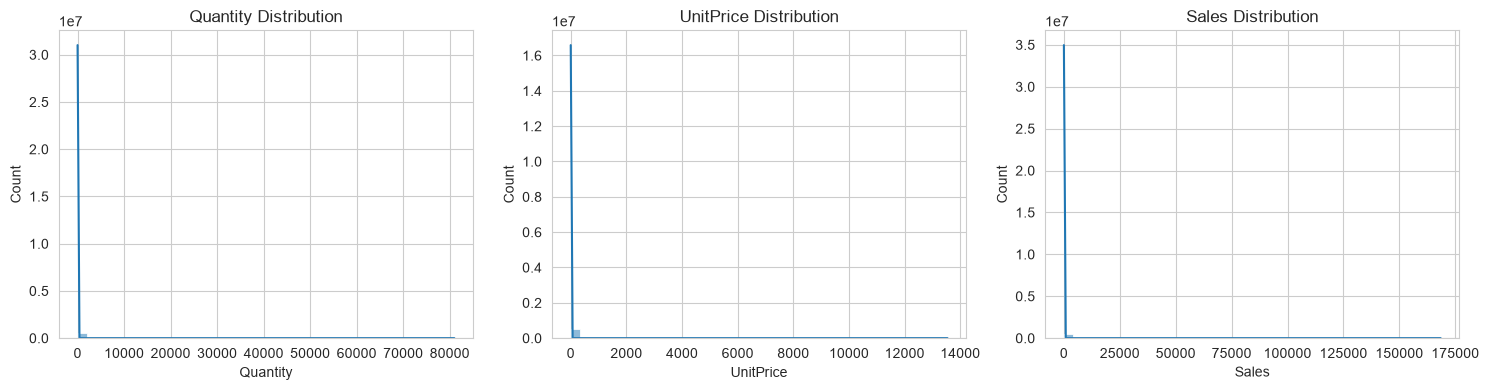

In [31]:
for col in ['Quantity', 'UnitPrice', 'Sales']:
    s = df_clean[col].dropna()
    skew_, kurt_ = stats.skew(s), stats.kurtosis(s)
    print(f"--- {col} ---")
    print(f"P25={s.quantile(0.25):.2f}, P50={s.quantile(0.5):.2f}, P75={s.quantile(0.75):.2f}")
    print(f"Skewness={skew_:.2f}, Kurtosis={kurt_:.2f}\n")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df_clean['Quantity'].dropna(), bins=40, kde=True, ax=axes[0])
axes[0].set_title('Quantity Distribution')

sns.histplot(df_clean['UnitPrice'].dropna(), bins=40, kde=True, ax=axes[1])
axes[1].set_title('UnitPrice Distribution')

sns.histplot(df_clean['Sales'].dropna(), bins=40, kde=True, ax=axes[2])
axes[2].set_title('Sales Distribution')

plt.tight_layout()
plt.show()

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Quốc gia nào đóng góp doanh thu cao nhất, chiếm bao nhiêu % tổng doanh thu?

In [32]:
# TODO
country_revenue = df_clean.groupby('Country')['Sales'].sum().reset_index()

country_revenue = country_revenue.sort_values(by='Sales', ascending=False)

total_revenue = country_revenue['Sales'].sum()

country_revenue['Percentage'] = (country_revenue['Sales'] / total_revenue) * 100

print(country_revenue.head(10))

top_country = country_revenue.iloc[0]
print(f"\n=> Quốc gia dẫn đầu: {top_country['Country']} với doanh thu {top_country['Sales']:,.2f} (chiếm {top_country['Percentage']:.2f}% tổng doanh thu)")

           Country        Sales  Percentage
36  United Kingdom  9025222.084   84.611315
24     Netherlands   285446.340    2.676055
10            EIRE   283453.960    2.657376
14         Germany   228867.140    2.145626
13          France   209715.110    1.966076
0        Australia   138521.310    1.298635
31           Spain    61577.110    0.577284
33     Switzerland    57089.900    0.535217
3          Belgium    41196.340    0.386215
32          Sweden    38378.330    0.359796

=> Quốc gia dẫn đầu: United Kingdom với doanh thu 9,025,222.08 (chiếm 84.61% tổng doanh thu)


## Câu hỏi 2: Sản phẩm nào bán chạy nhất theo doanh thu?

In [33]:
# TODO
product_revenue = df_clean.groupby('Description')['Sales'].sum().reset_index()

top_products = product_revenue.sort_values(by='Sales', ascending=False).head(5)

print("Top 5 sản phẩm bán chạy nhất theo doanh thu:")
print(top_products.to_string(index=False))

Top 5 sản phẩm bán chạy nhất theo doanh thu:
                       Description     Sales
                    DOTCOM POSTAGE 206248.77
          REGENCY CAKESTAND 3 TIER 174484.74
       PAPER CRAFT , LITTLE BIRDIE 168469.60
WHITE HANGING HEART T-LIGHT HOLDER 106292.77
                     PARTY BUNTING  99504.33


## Câu hỏi 3: Doanh số có tính mùa vụ theo tháng không?

   YearMonth        Sales
0    2010-12   823746.140
1    2011-01   691364.560
2    2011-02   523631.890
3    2011-03   717639.360
4    2011-04   537808.621
5    2011-05   770536.020
6    2011-06   761739.900
7    2011-07   719221.191
8    2011-08   759138.380
9    2011-09  1058590.172
10   2011-10  1154979.300
11   2011-11  1509496.330
12   2011-12   638792.680


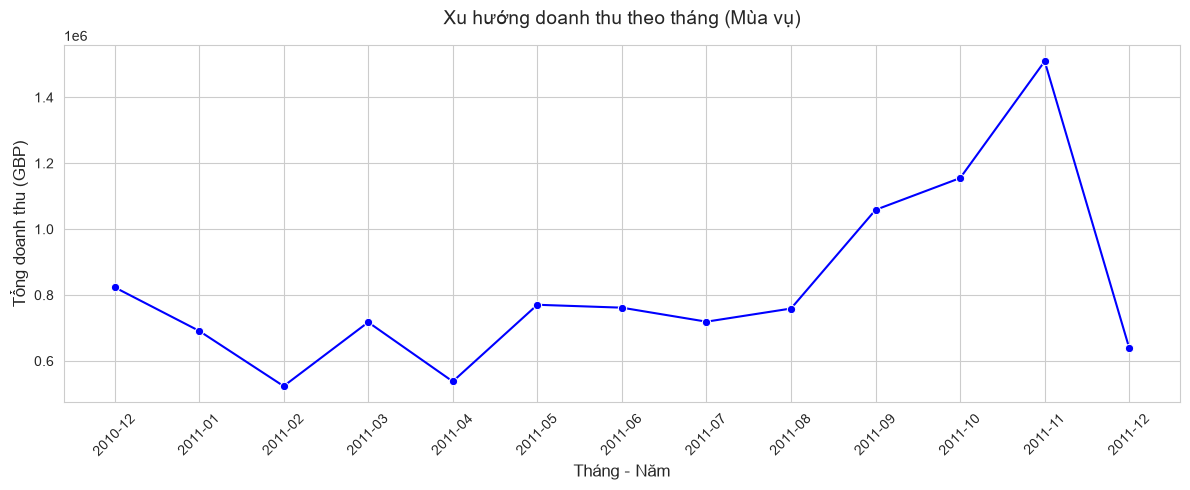

In [34]:
# TODO
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

monthly_revenue = df_clean.groupby('YearMonth')['Sales'].sum().reset_index()
monthly_revenue['YearMonth'] = monthly_revenue['YearMonth'].astype(str)

print(monthly_revenue)

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_revenue, x='YearMonth', y='Sales', marker='o', color='b')
plt.title("Xu hướng doanh thu theo tháng (Mùa vụ)", fontsize=14, pad=15)
plt.xlabel("Tháng - Năm", fontsize=12)
plt.ylabel("Tổng doanh thu (GBP)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

## Câu hỏi 4: Giá trị đơn hàng trung bình (Average Order Value) khác nhau thế nào giữa các quốc gia?

In [37]:
# TODO
order_revenue = df_clean.groupby(['Country', 'InvoiceNo'])['Sales'].sum().reset_index()

aov_by_country = order_revenue.groupby('Country')['Sales'].mean().reset_index()
aov_by_country.rename(columns={'Sales': 'AOV'}, inplace=True)

aov_by_country = aov_by_country.sort_values(by='AOV', ascending=False)

print("Top 10 quốc gia có Giá trị đơn hàng trung bình (AOV) cao nhất:")
print(aov_by_country.head(10).to_string(index=False))
print()
print('Những quốc gia có lượng khách mua hàng sỉ (wholesale) thường có AOV rất cao.')

Top 10 quốc gia có Giá trị đơn hàng trung bình (AOV) cao nhất:
    Country         AOV
  Singapore 3039.898571
Netherlands 3036.663191
  Australia 2430.198421
      Japan 1969.282632
    Lebanon 1693.880000
  Hong Kong 1426.527273
     Brazil 1143.600000
     Sweden 1066.064722
Switzerland 1057.220370
    Denmark 1053.074444

Những quốc gia có lượng khách mua hàng sỉ (wholesale) thường có AOV rất cao.


## Câu hỏi 5: Tỷ lệ giao dịch có dấu hiệu trả hàng/hủy (Quantity âm ở dữ liệu gốc) khác nhau thế nào giữa các quốc gia?

In [ ]:
# TODO
df['Is_Return'] = (df['Quantity'] < 0) | (df['InvoiceNo'].astype(str).str.startswith('C'))

return_stats = df.groupby('Country')['Is_Return'].agg(
    Total_Transactions='count',
    Return_Transactions='sum'
).reset_index()

return_stats['Return_Rate_%'] = (return_stats['Return_Transactions'] / return_stats['Total_Transactions']) * 100

return_stats = return_stats.sort_values(by='Return_Rate_%', ascending=False)

print("Top 10 quốc gia có tỷ lệ hoàn trả/hủy cao nhất:")
print(return_stats.head(10).to_string(index=False))


Top 10 quốc gia có tỷ lệ hoàn trả/hủy cao nhất:
       Country  Total_Transactions  Return_Transactions  Return_Rate_%
           USA                 291                  112      38.487973
Czech Republic                  30                    5      16.666667
         Malta                 127                   15      11.811024
         Japan                 358                   37      10.335196
  Saudi Arabia                  10                    1      10.000000
     Australia                1259                   74       5.877681
         Italy                 803                   45       5.603985
       Bahrain                  19                    1       5.263158
       Germany                9495                  453       4.770932
          EIRE                8196                  302       3.684724


## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

1. Vương quốc Anh đóng vai trò là thị trường trọng điểm tuyệt đối, chiếm áp đảo phần lớn tổng doanh thu, khẳng định đây là mô hình kinh doanh nội địa là chủ đạo.

2. Về mặt phân phối sản phẩm, doanh thu tập trung chủ yếu vào một nhóm nhỏ các mặt hàng bán chạy có số lượng tiêu thụ cực lớn thay vì các sản phẩm đơn giá cao.

3. Hoạt động kinh doanh thể hiện tính mùa vụ rất rõ rệt khi doanh số tăng mạnh vào các tháng cuối năm để phục vụ nhu cầu mua sắm và lễ hội cao điểm.

4. Giá trị đơn hàng trung bình (AOV) có sự phân hóa đáng kể giữa các quốc gia, phản ánh thói quen mua sỉ hoặc mua số lượng lớn của một số tệp khách hàng quốc tế đặc thù.

5. Cuối cùng, tỷ lệ giao dịch hoàn trả hoặc hủy đơn ghi nhận rải rác ở các thị trường, là yếu tố quan trọng cần được kiểm soát để tối ưu hóa hiệu quả vận hành và doanh thu thực tế.